In [16]:
import numpy as np
from pathlib import Path

processed_path = Path("/Users/carlasequero/Desktop/trabajo-fin-master/solution/data/splits/2026-08-16_processed_data_no_duplicates.npz")

data = np.load(processed_path)

print(data.files)

['X_train', 'X_val', 'X_test', 'X_id_train', 'X_id_val', 'X_id_test', 'X_err_train', 'X_err_val', 'X_err_test', 'y_train', 'y_val', 'y_test', 'y_id_train', 'y_id_val', 'y_id_test', 'y_ivar_train', 'y_ivar_val', 'y_ivar_test', 'gaia_wavelength', 'sdss_wavelength']


In [17]:
# Datos de entrada Gaia
X_train = data["X_train"]
X_val = data["X_val"]
X_test = data["X_test"]

# Errores de Gaia
X_err_train = data["X_err_train"]
X_err_val = data["X_err_val"]
X_err_test = data["X_err_test"]

# IDs de Gaia
X_id_train = data["X_id_train"]
X_id_val = data["X_id_val"]
X_id_test = data["X_id_test"]

# Datos objetivo SDSS
y_train = data["y_train"]
y_val = data["y_val"]
y_test = data["y_test"]

# IDs de SDSS
y_id_train = data["y_id_train"]
y_id_val = data["y_id_val"]
y_id_test = data["y_id_test"]

# Longitudes de onda
gaia_wavelength = data["gaia_wavelength"]
sdss_wavelength = data["sdss_wavelength"]

In [18]:
X_scale_train = np.nanmedian(np.abs(X_train), axis=1, keepdims=True)
X_scale_val = np.nanmedian(np.abs(X_val), axis=1, keepdims=True)
X_scale_test = np.nanmedian(np.abs(X_test), axis=1, keepdims=True)

y_scale_train = np.nanmedian(np.abs(y_train), axis=1, keepdims=True)
y_scale_val = np.nanmedian(np.abs(y_val), axis=1, keepdims=True)
y_scale_test = np.nanmedian(np.abs(y_test), axis=1, keepdims=True)

X_train_norm = X_train / X_scale_train
X_val_norm = X_val / X_scale_val
X_test_norm = X_test / X_scale_test

y_train_norm = y_train / y_scale_train
y_val_norm = y_val / y_scale_val
y_test_norm = y_test / y_scale_test

In [19]:
X_err_train_scaled = X_err_train / 1e-19
X_err_val_scaled = X_err_val / 1e-19
X_err_test_scaled = X_err_test / 1e-19
eps = 1e-8

In [20]:
snr_train = np.abs(X_train) / (X_err_train_scaled + eps)
snr_val = np.abs(X_val) / (X_err_val_scaled + eps)
snr_test = np.abs(X_test) / (X_err_test_scaled + eps)

In [21]:
snr_p99 = np.nanpercentile(snr_train, 99)

snr_train = np.clip(snr_train, 0, snr_p99)
snr_val = np.clip(snr_val, 0, snr_p99)
snr_test = np.clip(snr_test, 0, snr_p99)

In [22]:
snr_mean = np.nanmean(snr_train, axis=0)
snr_std = np.nanstd(snr_train, axis=0)

snr_train_norm = (snr_train - snr_mean) / snr_std
snr_val_norm = (snr_val - snr_mean) / snr_std
snr_test_norm = (snr_test - snr_mean) / snr_std

In [23]:
X_model_with_snr_train = np.concatenate(
    [X_train_norm, snr_train_norm],
    axis=1
)

X_model_with_snr_val = np.concatenate(
    [X_val_norm, snr_val_norm],
    axis=1
)

X_model_with_snr_test = np.concatenate(
    [X_test_norm, snr_test_norm],
    axis=1
)

print("X_train_norm:", X_train_norm.shape)
print("snr_train_norm:", snr_train_norm.shape)
print("Entrada final:", X_model_with_snr_train.shape)

X_train_norm: (32656, 201)
snr_train_norm: (32656, 201)
Entrada final: (32656, 402)


In [24]:

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

n_gaia = X_model_with_snr_train.shape[1]
n_sdss = y_train.shape[1]

model_snr = models.Sequential([
    layers.Input(shape=(n_gaia,)),

    layers.Dense(512),#, activation="elu"),#relu
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024, activation="elu"),
    
    layers.Dense(1024),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024, activation="elu"),

    layers.Dense(n_sdss)
])

model_snr.compile(
    optimizer=Adam(learning_rate=1e-4, clipnorm = 1.0),
    loss= tf.keras.losses.Huber(delta=1.0),
    metrics=["mae", "mse"]
)

model_snr.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 512)            │       206,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 2666)           │     2,732,650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,563,498 (21.22 MB)

 Trainable params: 5,563,498 (21.22 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5, # 4 EN SU OPTIMO ESTADO, 
    min_delta = 1e-4,
    restore_best_weights=True
)

from tensorflow.keras.callbacks import ReduceLROnPlateau
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

history = model_snr.fit(
    X_model_with_snr_train,
    y_train_norm,
    validation_data=(X_model_with_snr_val, y_val_norm),
    epochs=50,
    batch_size=64, #32 PARA QUE VAYA EN SU OPTIMO ESTADO
    callbacks=[early_stop,reduce_lr],
    verbose=1
)


Epoch 1/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 21s 38ms/step - loss: 0.0671 - mae: 0.1999 - mse: 0.1508 - val_loss: 0.0049 - val_mae: 0.0574 - val_mse: 0.0148 - learning_rate: 1.0000e-04
Epoch 2/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 19s 37ms/step - loss: 0.0047 - mae: 0.0545 - mse: 0.0122 - val_loss: 0.0046 - val_mae: 0.0533 - val_mse: 0.0141 - learning_rate: 1.0000e-04
Epoch 3/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 19s 37ms/step - loss: 0.0044 - mae: 0.0520 - mse: 0.0115 - val_loss: 0.0043 - val_mae: 0.0503 - val_mse: 0.0134 - learning_rate: 1.0000e-04
Epoch 4/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - loss: 0.0043 - mae: 0.0507 - mse: 0.0115 - val_loss: 0.0040 - val_mae: 0.0491 - val_mse: 0.0129 - learning_rate: 1.0000e-04
Epoch 5/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - loss: 0.0040 - mae: 0.0490 - mse: 0.0105 - val_loss: 0.0039 - val_mae: 0.0485 - val_mse: 0.0125 - learning_rate: 1.0000e-04
Epoch 6/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 19s 37ms/step - loss: 0.0038 - mae: 0.0485 - mse: 0.0097 - v

In [26]:
y_pred_norm = model_snr.predict(X_model_with_snr_test)
y_pred = y_pred_norm * y_scale_test

128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [27]:
test_loss, test_mae, test_mse = model_snr.evaluate(
    X_model_with_snr_test,
    y_test_norm,
    verbose=1
)

128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0031 - mae: 0.0424 - mse: 0.0089


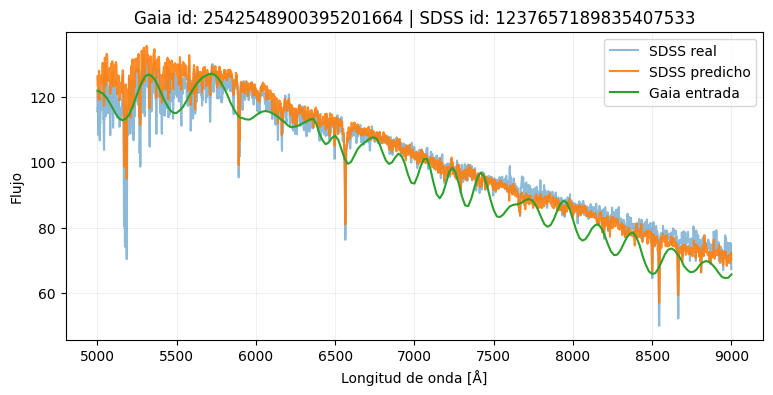

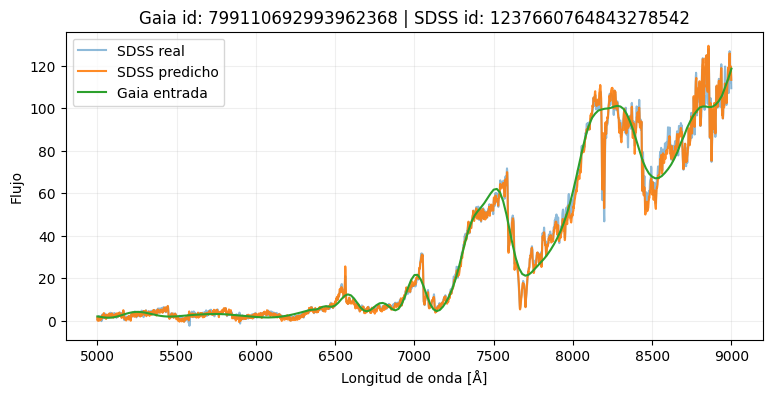

In [28]:
# Importamos funciones a usar para analizar resultados
from model_functions import (
    plot_training_metrics,
    plot_prediction_example,
    plot_worst_best_predictions
)

plot_prediction_example(
    245,
    sdss_wavelength,
    gaia_wavelength,
    y_test,
    y_pred,
    y_id_test,
    X_test,
    X_id_test
)

plot_prediction_example(
    10,
    sdss_wavelength,
    gaia_wavelength,
    y_test,
    y_pred,
    y_id_test,
    X_test,
    X_id_test
)

In [29]:
predictions_path = Path("../data/predictions/predicciones_modelos_SNR.npz")
predictions_path.parent.mkdir(parents=True, exist_ok=True)

np.savez_compressed(
    predictions_path,
    
    # Predicciones de los modelos testeados
    y_pred=y_pred
)